In [32]:
import time
import random
import csv
import matplotlib.pyplot as plt
from phe import paillier
import numpy as np


In [33]:
# --- Experiment setup ---
p = 18446744073709551557
bit_length = p.bit_length()
n_values = [20,100,500,1000,1500]
num_runs = 3  # repeat each method 5 times for stability

times_plain, times_paillier, times_shamir, times_dp, errors_dp = [], [], [], [], []

print("Starting runtime comparison")
print(f"Prime p set to {p.bit_length()} bits")
print(f"n_values = {n_values}")
print(f"Each method runs {num_runs} times per n\n")


Starting runtime comparison
Prime p set to 64 bits
n_values = [20, 100, 500, 1000, 1500]
Each method runs 3 times per n



In [34]:
def plain_avg(values):
    return sum(values) / len(values)
    

In [35]:
# --- 1. Key Generation Phase ---
def paillier_keygen(n_length=4096):
    public_key, private_key = paillier.generate_paillier_keypair(n_length=n_length)
    return public_key, private_key

# --- 2. Encryption Phase ---
def paillier_encrypt(values, public_key):
    # Encrypt each integer using the public key
    encrypted_values = [public_key.encrypt(v) for v in values]
    return encrypted_values

# --- 3. Computation Phase ---
def paillier_compute(encrypted_values):
    # Perform homomorphic addition (encrypted sum)
    encrypted_sum = sum(encrypted_values)
    return encrypted_sum

# --- 4. Decryption Phase ---
def paillier_decrypt(encrypted_sum, private_key, n):
    decrypted_sum = private_key.decrypt(encrypted_sum)
    avg = decrypted_sum / n
    return avg

In [36]:
def compute_modular(coefficients, p, x):
    res = 0
    for coeff in reversed(coefficients):
        res = (res * x + coeff) % p
    return res

def shamir_share(secret, n, threshold, prime):
    coefficients = [secret] + [random.randint(0, prime - 1) for _ in range(threshold - 1)]
    shares = [(i, compute_modular(coefficients, prime, i)) for i in range(1, n + 1)]
    return shares  # list of (x, y)

def compute_l(j, x_values, p):
    x_j = x_values[j]
    numerator = 1
    denominator = 1
    for k, x_k in enumerate(x_values):
        if k != j:
            numerator = (numerator * (-x_k)) % p
            denominator = (denominator * (x_j - x_k)) % p
    denom_inv = pow(denominator, -1, p)
    return (numerator * denom_inv) % p

import time

def shamir_avg(values, n, p):
    threshold = n // 2 + 1
    phase_times = {}

    # --- Phase 1: Sharing each secret ---
    start = time.perf_counter()
    all_shares = [shamir_share(secret, n, threshold, p) for secret in values]
    phase_times["share"] = (time.perf_counter() - start) * 1000

    # --- Phase 2: Combine shares (computation) ---
    start = time.perf_counter()
    aggregated_shares = []
    for i in range(n):
        total_y = sum(share[i][1] for share in all_shares) % p
        aggregated_shares.append((all_shares[0][i][0], total_y))
    phase_times["compute"] = (time.perf_counter() - start) * 1000

    # --- Phase 3: Reconstruction ---
    start = time.perf_counter()
    x_values = [x for x, _ in aggregated_shares[:threshold]]
    y_values = [y for _, y in aggregated_shares[:threshold]]
    total = 0
    for j in range(threshold):
        l = compute_l(j, x_values, p)
        total = (total + y_values[j] * l) % p
    inv_n = pow(len(values), -1, p)
    average = (total * inv_n) % p
    phase_times["reconstruct"] = (time.perf_counter() - start) * 1000

    return average, phase_times


In [ ]:
def dp_avg(values, sensitivity, epsilon=1.0):
    n = len(values)
    true_avg = sum(values) / n
    noise = np.random.laplace(loc=0, scale = sensitivity / epsilon, size = 1)
    return true_avg + noise

In [ ]:
for n in n_values:
    print(f"\n=== Running for n = {n} ===")
    values = [random.randint(0, n+1) for _ in range(n)]

    # --- Plain ---
    print("Plain averaging ...", end="")
    runtimes = []
    for _ in range(num_runs):
        start = time.perf_counter()
        plain_avg(values)
        elapsed_ms = (time.perf_counter() - start) * 1000
        runtimes.append(elapsed_ms)
    avg_time = sum(runtimes) / num_runs
    times_plain.append(avg_time)
    print("done")

    # --- Paillier (phase-separated) for this n ---
    print("Paillier averaging...", end="")
    keygen_times, encrypt_times, hom_compute_times, decrypt_times = [], [], [], []
    for _ in range(num_runs):
        # Key generation
        start = time.perf_counter()
        public_key, private_key = paillier_keygen()
        keygen_times.append((time.perf_counter() - start) * 1000)

        # Encryption
        start = time.perf_counter()
        enc = paillier_encrypt(values, public_key)
        encrypt_times.append((time.perf_counter() - start) * 1000)

        # Homomorphic computation
        start = time.perf_counter()
        res = paillier_compute(enc)
        hom_compute_times.append((time.perf_counter() - start) * 1000)

        # Decryption
        start = time.perf_counter()
        paillier_decrypt(res, private_key, len(values))
        decrypt_times.append((time.perf_counter() - start) * 1000)

    times_paillier.append({
        "keygen": sum(keygen_times) / num_runs,
        "encrypt": sum(encrypt_times) / num_runs,
        "compute": sum(hom_compute_times) / num_runs,
        "decrypt": sum(decrypt_times) / num_runs
    })
    print("done")

    # --- Shamir for this n ---
    print("Shamir averaging ...", end="")
    share_times, compute_times_sh, reconstruct_times = [], [], []
    for _ in range(num_runs):
        a, t = shamir_avg(values, n, p)
        share_times.append(t["share"])
        compute_times_sh.append(t["compute"])
        reconstruct_times.append(t["reconstruct"])

    times_shamir.append({
        "share": sum(share_times) / num_runs,
        "compute": sum(compute_times_sh) / num_runs,
        "reconstruct": sum(reconstruct_times) / num_runs
    })
    print("done")
    

    # --- Differential Privacy ---
    print("Differential Privacy averaging ...", end="")
    dp_runtimes, dp_errors_run = [], []
    sensitivity = (np.max(values) - np.min(values)) / n 
    for _ in range(num_runs):
        start = time.perf_counter()
        dp_result = dp_avg(values, sensitivity)
        elapsed_ms = (time.perf_counter() - start) * 1000
        dp_runtimes.append(elapsed_ms)

        true_avg = sum(values) / n
        dp_errors_run.append(abs(dp_result - true_avg))

    avg_dp_time = np.mean(dp_runtimes)
    avg_dp_error = np.mean(dp_errors_run)

    # Store the average results globally
    times_dp.append(avg_dp_time)
    errors_dp.append(avg_dp_error)

    print("done")

    
# --- Summary ---
print("\n=== Summary ===")
for i, n in enumerate(n_values):
    print(f"\nn={n}")
    print(f"Plain avg: {times_plain[i]:.2f} ms")
    print(f"Paillier phases: {times_paillier[i]}")
    print(f"Shamir phases:  {times_shamir[i]}")






=== Running for n = 20 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 100 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 100 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 500 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 500 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Shamir averaging ...done
Differential Privacy averaging ...done

=== Running for n = 1000 ===
Plain averaging ...done
Paillier averaging...done
Differential Privacy averaging ...done

=== Running for n = 1000 ===
Plain averaging ...done
Paillier averaging...done
Shamir averaging ...done
Shamir averaging ...done
Differential

In [39]:
# --- Save results ---
with open('runtime_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    # save results in milliseconds (paillier/shamir stored as dicts)
    writer.writerow(['n', 'plain_ms', 'paillier_ms', 'shamir_ms'])
    for i, n in enumerate(n_values):
        writer.writerow([n, times_plain[i], times_paillier[i], times_shamir[i], times_dp[i]])

print("\nWrote runtime_results.csv")
print("Results (n, plain_ms, paillier_ms, shamir_ms, dp_ms):")
for i, n in enumerate(n_values):
    print(f"{n}: {times_plain[i]:.2f}ms, {times_paillier[i]}, {times_shamir[i]}, {times_dp[i]}")


Wrote runtime_results.csv
Results (n, plain_ms, paillier_ms, shamir_ms, dp_ms):
20: 0.00ms, {'keygen': 628.8154402282089, 'encrypt': 923.3932735708853, 'compute': 0.3458370144168536, 'decrypt': 16.941627953201532}, {'share': 0.5000173890342315, 'compute': 0.02245061720410983, 'reconstruct': 0.03800160872439543}, 1.0017323462913434
100: 0.00ms, {'keygen': 612.178348004818, 'encrypt': 4629.806481224175, 'compute': 1.7151995562016964, 'decrypt': 16.897842365627486}, {'share': 46.34329273054997, 'compute': 0.4110203590244055, 'reconstruct': 0.6005666218698025}, 0.004190408314267795
500: 0.00ms, {'keygen': 404.19717761687934, 'encrypt': 23128.059071333457, 'compute': 8.527193606520692, 'decrypt': 17.251735630755622}, {'share': 5460.314630297944, 'compute': 13.845758745446801, 'reconstruct': 13.430081385498246}, 0.00738507757584254
1000: 0.01ms, {'keygen': 622.3458020637432, 'encrypt': 46238.12460705327, 'compute': 17.129017040133476, 'decrypt': 17.210376681759953}, {'share': 44009.98915227

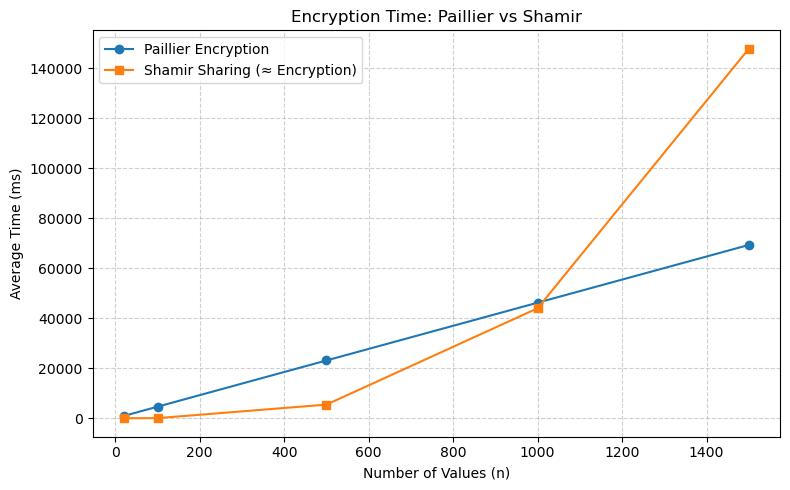

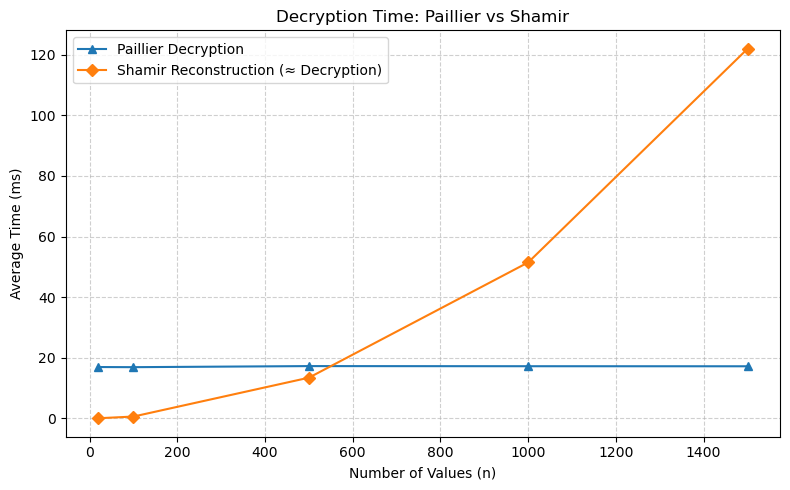

In [40]:
# --- Compare Paillier vs Shamir: Encryption and Decryption ---

# Extract Paillier phase times
paillier_encrypt_time = [times_paillier[i]["encrypt"] for i in range(len(times_paillier))]
paillier_decrypt_time = [times_paillier[i]["decrypt"] for i in range(len(times_paillier))]

# For Shamir, encryption ≈ sharing phase, decryption ≈ reconstruction phase
shamir_encrypt_time = [times_shamir[i]["share"] for i in range(len(times_shamir))]
shamir_decrypt_time = [times_shamir[i]["reconstruct"] for i in range(len(times_shamir))]

# --- Plot Encryption Time Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, paillier_encrypt_time, marker='o', label="Paillier Encryption")
plt.plot(n_values, shamir_encrypt_time, marker='s', label="Shamir Sharing (≈ Encryption)")
plt.xlabel("Number of Values (n)")
plt.ylabel("Average Time (ms)")
plt.title("Encryption Time: Paillier vs Shamir")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot Decryption Time Comparison ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, paillier_decrypt_time, marker='^', label="Paillier Decryption")
plt.plot(n_values, shamir_decrypt_time, marker='D', label="Shamir Reconstruction (≈ Decryption)")
plt.xlabel("Number of Values (n)")
plt.ylabel("Average Time (ms)")
plt.title("Decryption Time: Paillier vs Shamir")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

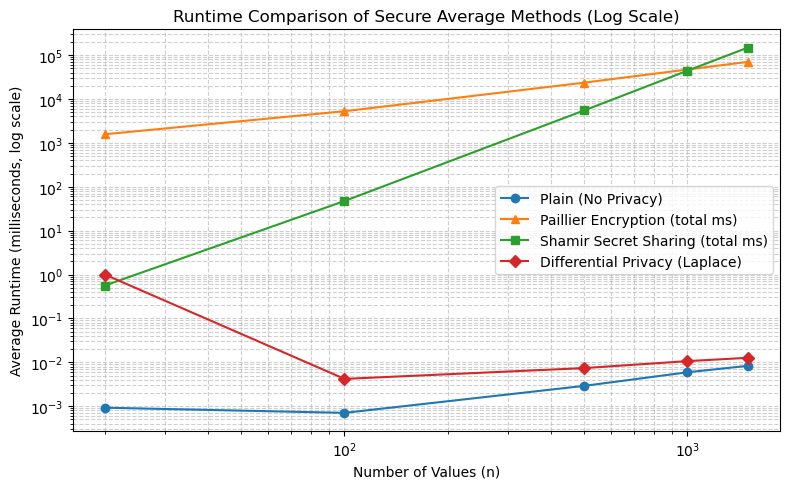

Plot displayed. Done.


In [41]:
# --- Compare the total running time  ---
plt.figure(figsize=(8, 5))

# For plotting we need numeric values; extract a representative Paillier total time and Shamir total time
paillier_totals = [sum(times_paillier[i].values()) for i in range(len(times_paillier))]
shamir_totals = [sum(times_shamir[i].values()) for i in range(len(times_shamir))]

plt.plot(n_values, times_plain, marker='o', label="Plain (No Privacy)")
plt.plot(n_values, paillier_totals, marker='^', label="Paillier Encryption (total ms)")
plt.plot(n_values, shamir_totals, marker='s', label="Shamir Secret Sharing (total ms)")
plt.plot(n_values, times_dp, marker='D', label="Differential Privacy (Laplace)")

plt.xlabel("Number of Values (n)")
plt.ylabel("Average Runtime (milliseconds, log scale)")
plt.title("Runtime Comparison of Secure Average Methods (Log Scale)")

# 🔹 Apply logarithmic scale to y-axis
plt.yscale("log")
plt.xscale("log")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("Plot displayed. Done.")


In [ ]:
# --- Accuracy Analysis (using MSE instead of MAE) ---
print("\n=== Accuracy Analysis (MSE) ===")

mse_plain, mse_paillier, mse_shamir, mse_dp = [], [], [], []

# Define DP parameters
a, b = 0,n+1 
epsilon = 1.0

for i, n in enumerate(n_values):
    values = [random.randint(a, b) for _ in range(n)]
    true_avg = sum(values) / n

    # --- Plain ---
    plain_res = plain_avg(values)

    # --- Paillier ---
    public_key, private_key = paillier_keygen()
    enc_vals = paillier_encrypt(values, public_key)
    paillier_sum = paillier_compute(enc_vals)
    paillier_res = paillier_decrypt(paillier_sum, private_key, len(values))

    # --- Shamir (unwrap modular result) ---
    shamir_res, _ = shamir_avg(values, n, p)
    
    # --- Differential Privacy (Laplace Mechanism with correct sensitivity) ---
    sensitivity = (b - a) / n
    dp_res = dp_avg(values, sensitivity)

    # --- Compute Mean Squared Errors ---
    mse_plain.append((plain_res - true_avg) ** 2)
    mse_paillier.append((paillier_res - true_avg) ** 2)
    mse_shamir.append((shamir_res - true_avg) ** 2)
    mse_dp.append((dp_res - true_avg) ** 2)

# --- Plot Accuracy Comparison (MSE) ---
plt.figure(figsize=(8, 5))
plt.plot(n_values, mse_plain, marker='o', label='Plain (No Privacy)')
plt.plot(n_values, mse_paillier, marker='^', label='Paillier')
plt.plot(n_values, mse_shamir, marker='s', label='Shamir (mod corrected)')
plt.plot(n_values, mse_dp, marker='D', label='Differential Privacy (Laplace)')
plt.xlabel("Number of Values (n)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Accuracy Comparison of Averaging Methods (MSE)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



=== Accuracy Analysis (MSE) ===
